# Centralidades de grado y eigenvector


Cargamos las librerías


In [46]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import matplotlib.cm as cm
import matplotlib.colors as mcolors
from IPython.display import display

from typing import List, Tuple
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BLUES = plt.cm.rainbow

In [47]:
from typing import List, Tuple

V: List[str] = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "GOOG", "AVGO", "META", "TSLA", "BRK.B",
    "JPM", "V", "MA", "WMT", "COST", "ORCL", "LLY", "XOM", "JNJ", "PLTR",
    "BAC", "ABBV", "MU", "HD", "NFLX", "AMD", "PG", "GE", "CVX", "UNH"
]

E: List[Tuple[str, str]] = [
    # semiconductores / hardware / computo
    ("MU", "NVDA"),
    ("AVGO", "AAPL"),

    ("NVDA", "MSFT"), ("NVDA", "AMZN"), ("NVDA", "GOOG"), ("NVDA", "GOOGL"),
    ("NVDA", "ORCL"), ("NVDA", "META"), ("NVDA", "TSLA"),

    ("AMD", "AMZN"), ("AMD", "MSFT"), ("AMD", "ORCL"), ("AMD", "TSLA"),

    # nube / servicios
    ("AMZN", "NFLX"),
    ("AMZN", "XOM"), ("AMZN", "JNJ"), ("AMZN", "ABBV"),
    ("AMZN", "PLTR"),

    ("MSFT", "CVX"), ("MSFT", "GE"), ("MSFT", "UNH"),
    ("MSFT", "PLTR"),

    ("GOOGL", "PLTR"),
    ("ORCL", "PLTR"),

    # retail
    ("AAPL", "WMT"), ("AAPL", "COST"),
    ("PG", "WMT"),
    ("BRK.B", "WMT"),

    # pagos / tarjetas
    ("V", "COST"), ("V", "HD"), ("V", "BAC"),
    ("MA", "HD"), ("MA", "WMT"), ("MA", "AAPL"), ("MA", "BAC"),
    ("JPM", "AAPL"),

    # farmacia
    ("LLY", "AMZN"),
]

In [48]:
G = nx.Graph()
G.add_nodes_from(V)
G.add_edges_from(E)

In [49]:
deg_centralidades = nx.degree_centrality(G)
eig_centralidades = nx.eigenvector_centrality(G)

eig_sizes = np.array([eig_centralidades[n] for n in G])
deg_colors = np.array([deg_centralidades[i] for i in G])


def sum1_dict(d):
    s = sum(d.values())
    return {k: (v / s if s != 0 else 0.0) for k, v in d.items()}


deg_centralidades = sum1_dict(deg_centralidades)
eig_centralidades = sum1_dict(eig_centralidades)

# Centralidades


Padme es la que tiene mas coapariciones en la pelicula, y tambien la que tiene las coapariciones con personajes significativos (significativos es que sus vecinos tambien tienen coapariciones con otros)


In [50]:
deg_sorted = sorted(deg_centralidades.items(),
                    key=lambda kv: kv[1], reverse=True)
df_deg = pd.DataFrame(deg_sorted, columns=["node", "degree_centrality"])
df_deg.head(10)

,node,degree_centrality
0,NVDA,0.108108
1,AMZN,0.108108
2,MSFT,0.081081
3,AAPL,0.067568
4,MA,0.054054
5,WMT,0.054054
6,PLTR,0.054054
7,AMD,0.054054
8,V,0.040541
9,ORCL,0.040541


In [51]:
eig_sorted = sorted(eig_centralidades.items(),
                    key=lambda kv: kv[1], reverse=True)
df_eig = pd.DataFrame(eig_sorted, columns=["node", "eigenvector_centrality"])
df_eig.head(10)

,node,eigenvector_centrality
0,NVDA,0.124403
1,AMZN,0.112821
2,MSFT,0.094456
3,PLTR,0.086211
4,AMD,0.086211
5,ORCL,0.075918
6,GOOGL,0.053868
7,TSLA,0.053868
8,GOOG,0.031818
9,META,0.031818


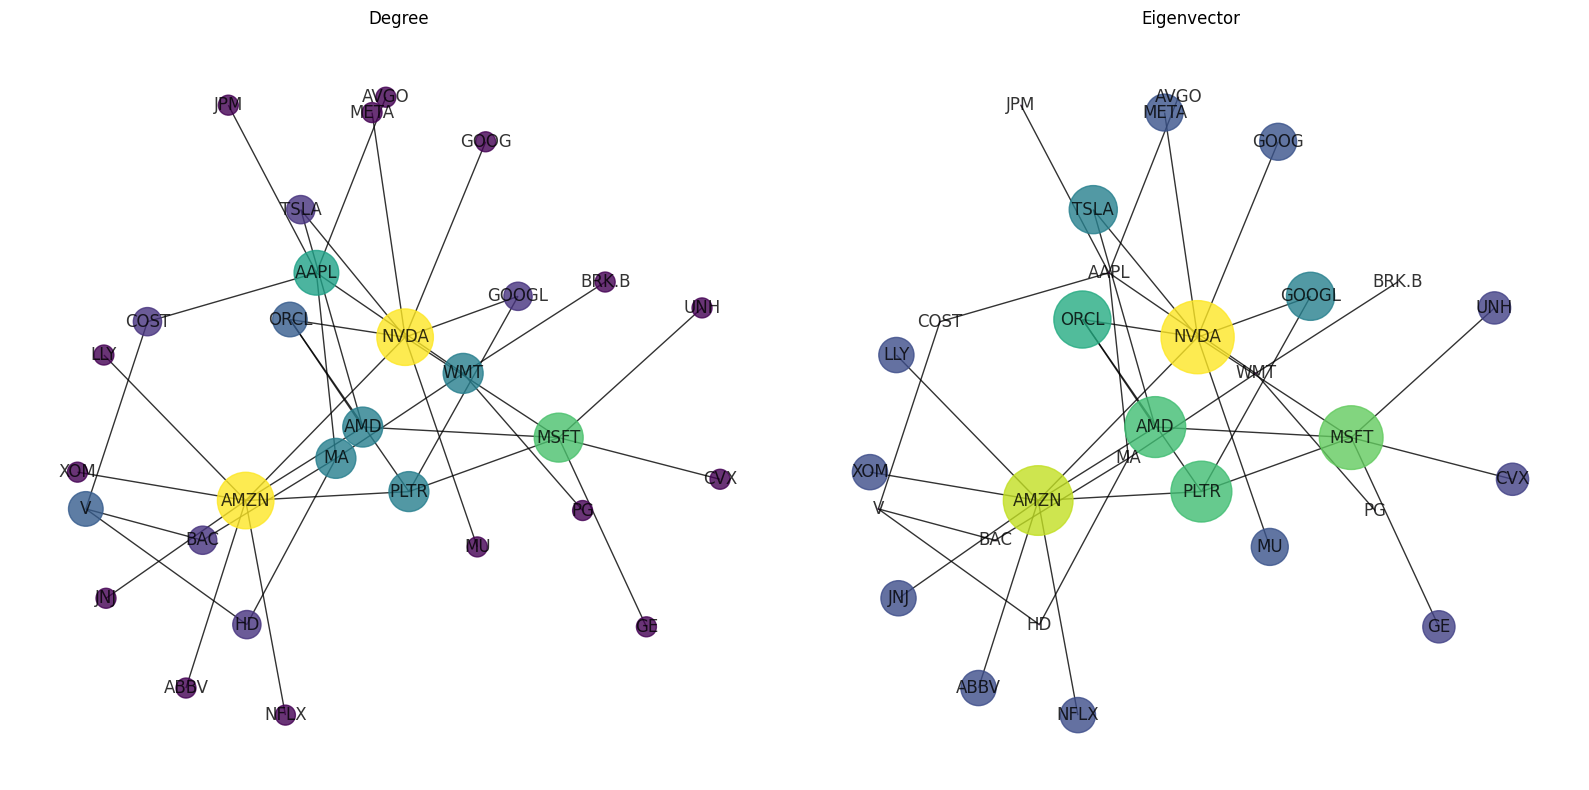

In [52]:
plt.figure(figsize=(16, 8))


plt.subplot(1, 2, 1)
nx.draw_kamada_kawai(G, node_size=6000*deg_colors,
                     node_color=deg_colors, with_labels=True, alpha=0.8)
plt.title("Degree")

plt.subplot(1, 2, 2)
nx.draw_kamada_kawai(G, node_size=6000*eig_sizes,
                     node_color=eig_sizes, with_labels=True, alpha=0.8)
plt.title("Eigenvector")

plt.tight_layout()
plt.show()

**Los que tienen medida de centralidad de eigenvector mas grande tambien coinciden con la parte de la red que tiene mayor grado.**


# $\text{degree} - \text{eigenvector}$


Conseguimos las diferencias de $\text{degree} - \text{eigenvector}$, nos quedamos con las mas positivas, las mas negativas, las mas cercanas a 0 y las mas alejadas.


## Funciones


In [53]:
# top diferencias

diff = {n: (deg_centralidades[n] - eig_centralidades[n]) for n in G.nodes()}
k = 10

top_pos = [n for n, v in sorted(
    diff.items(), key=lambda kv: kv[1], reverse=True)[:k]]

top_neg = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1])[:k]]

closest0 = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]))[:k]]

furthest = [n for n, v in sorted(
    diff.items(), key=lambda kv: abs(kv[1]), reverse=True)[:k]]

In [54]:
# plot centralidades

def plot_centralidades(top_pos, title: str = '', nodesize=10000):
    top_pos_eig = np.array([eig_centralidades[n] for n in top_pos])
    top_pos_deg = np.array([deg_centralidades[n] for n in top_pos])
    top_pos_diff = np.array([diff[n] for n in top_pos])

    plt.figure(figsize=(24, 8))
    pos = nx.kamada_kawai_layout(G)

    plt.subplot(1, 3, 2)
    nx.draw_networkx_edges(G, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G, pos, nodelist=top_pos, node_size=nodesize*top_pos_eig,
                           node_color=top_pos_eig, alpha=0.6)
    nx.draw_networkx_labels(
        G, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("Eigenvector")
    plt.axis("off")

    plt.subplot(1, 3, 1)
    nx.draw_networkx_edges(G, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G, pos, nodelist=top_pos, node_size=nodesize*top_pos_deg,
                           node_color=top_pos_deg, alpha=0.6)
    nx.draw_networkx_labels(
        G, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("Degree")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    nx.draw_networkx_edges(G, pos, alpha=0.15, width=1.0)
    nx.draw_networkx_nodes(G, pos, nodelist=top_pos, node_size=nodesize*np.abs(top_pos_diff),
                           node_color=top_pos_diff, alpha=0.6)
    nx.draw_networkx_labels(
        G, pos, labels={n: n for n in top_pos}, font_size=10)
    plt.title("Diff")
    plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [55]:
# tabla

def tabla(top_pos, digits):
    df = (
        pd.DataFrame({
            "node": top_pos,
            "degree": [deg_centralidades[n] for n in top_pos],
            "eigenvector": [eig_centralidades[n] for n in top_pos],
            "diff": [diff[n] for n in top_pos],
        })
        .reset_index(drop=True)
    )

    display(
        df.style.format(
            {
                "eigenvector": f"{{:.{digits}f}}",
                "degree": f"{{:.{digits}f}}",
                "diff": f"{{:.{digits}f}}",
            }
        )
    )
    return df

In [56]:
# vecinos

import matplotlib


def ego_layers(G, center, max_radius):
    layers = []
    prev = set()
    for r in range(0, max_radius + 1):
        nodes_r = set(nx.ego_graph(G, center, radius=r).nodes())
        layers.append(nodes_r - prev)  # exactly distance r
        prev = nodes_r
    return layers  # [L0, L1, ..., Lmax]


def layer_color_map(layers, cmap_name="Reds", stops=None, default="lightgray"):
    # stops: list of floats in [0,1] for each layer (0..R). Higher => darker in Reds.
    if stops is None:
        # for radius 3: [dark, ..., light]
        stops = np.linspace(0.95, 0.35, num=len(layers))

    cmap = matplotlib.colormaps[cmap_name]
    layer_to_color = {i: cmap(stops[i]) for i in range(len(layers))}

    node_to_layer = {}
    for i, L in enumerate(layers):
        for n in L:
            node_to_layer[n] = i

    def colors_for(subG):
        cols = []
        for n in subG.nodes():
            i = node_to_layer.get(n, None)
            cols.append(
                layer_to_color[i] if i is not None else mcolors.to_rgba(default))
        return cols

    return colors_for


def plot_ego_radii_3panel(G, center, radii=(1, 2, 3), layout="kamada_kawai", figsize=(18, 6)):
    max_r = max(radii)
    layers = ego_layers(G, center, max_r)          # L0..Lmax (exact distance)
    colors_for = layer_color_map(layers, cmap_name="Reds")

    plt.figure(figsize=figsize)
    for i, r in enumerate(radii, start=1):
        SG = nx.ego_graph(G, center, radius=r)

        n_nodes = SG.number_of_nodes()
        n_edges = SG.number_of_edges()
        density = nx.density(SG) if n_nodes > 1 else 0.0

        # how many nodes at each exact distance from center (up to r)
        layer_counts = [len(layers[d]) for d in range(r + 1)]
        # neighbors in each step (excluding the center at distance 0)
        neighbor_counts = layer_counts[1:]  # distances 1..r

        plt.subplot(1, 3, i)
        if layout == "circular":
            pos = nx.circular_layout(SG)
            nx.draw(SG, pos, node_color=colors_for(
                SG), with_labels=True, font_size=8)
        else:
            nx.draw_kamada_kawai(SG, node_color=colors_for(
                SG), with_labels=True, font_size=8)

        plt.title(
            f"Nodo {center} (radio={r})\n"
            f"Nodos={n_nodes}, Aristas={n_edges}, Densidad={density:.3f}\n"
            f"Vecinos por distancia={neighbor_counts}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()


def plot_ego_radii_4panel(G, center, radii=(1, 2, 3, 4), layout="kamada_kawai", figsize=(24, 6)):
    max_r = max(radii)
    layers = ego_layers(G, center, max_r)
    colors_for = layer_color_map(layers, cmap_name="Reds")

    plt.figure(figsize=figsize)
    for i, r in enumerate(radii, start=1):
        SG = nx.ego_graph(G, center, radius=r)

        n_nodes = SG.number_of_nodes()
        n_edges = SG.number_of_edges()
        density = nx.density(SG) if n_nodes > 1 else 0.0

        layer_counts = [len(layers[d]) for d in range(r + 1)]
        neighbor_counts = layer_counts[1:]

        plt.subplot(1, 4, i)
        if layout == "circular":
            pos = nx.circular_layout(SG)
            nx.draw(SG, pos, node_color=colors_for(
                SG), with_labels=True, font_size=8)
        else:
            nx.draw_kamada_kawai(SG, node_color=colors_for(
                SG), with_labels=True, font_size=8)

        plt.title(
            f"Nodo {center} (radio={r})\n"
            f"Nodos={n_nodes}, Aristas={n_edges}, Densidad={density:.3f}\n"
            f"Vecinos por distancia={neighbor_counts}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Top positivos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen muchos vecinos, pero sus vecinos no son muy importantes.

- Nodo tiene muchos vecinos
- Los vecinos tienen pocos vecinos

Contagian directamente a muchos, pero no se propaga mucho


# **!!!! Solo los componentes de la subred mas grande tienen eigenvector!!!** 

In [57]:
df_top_pos = tabla(top_pos=top_pos, digits=4)

,node,degree,eigenvector,diff
0,AAPL,0.0676,0.0000,0.0676
1,WMT,0.0541,0.0000,0.0540
2,MA,0.0541,0.0000,0.0540
3,V,0.0405,0.0000,0.0405
4,BAC,0.0270,0.0000,0.0270
5,HD,0.0270,0.0000,0.0270
6,COST,0.0270,0.0000,0.0270
7,BRK.B,0.0135,0.0000,0.0135
8,PG,0.0135,0.0000,0.0135
9,AVGO,0.0135,0.0000,0.0135


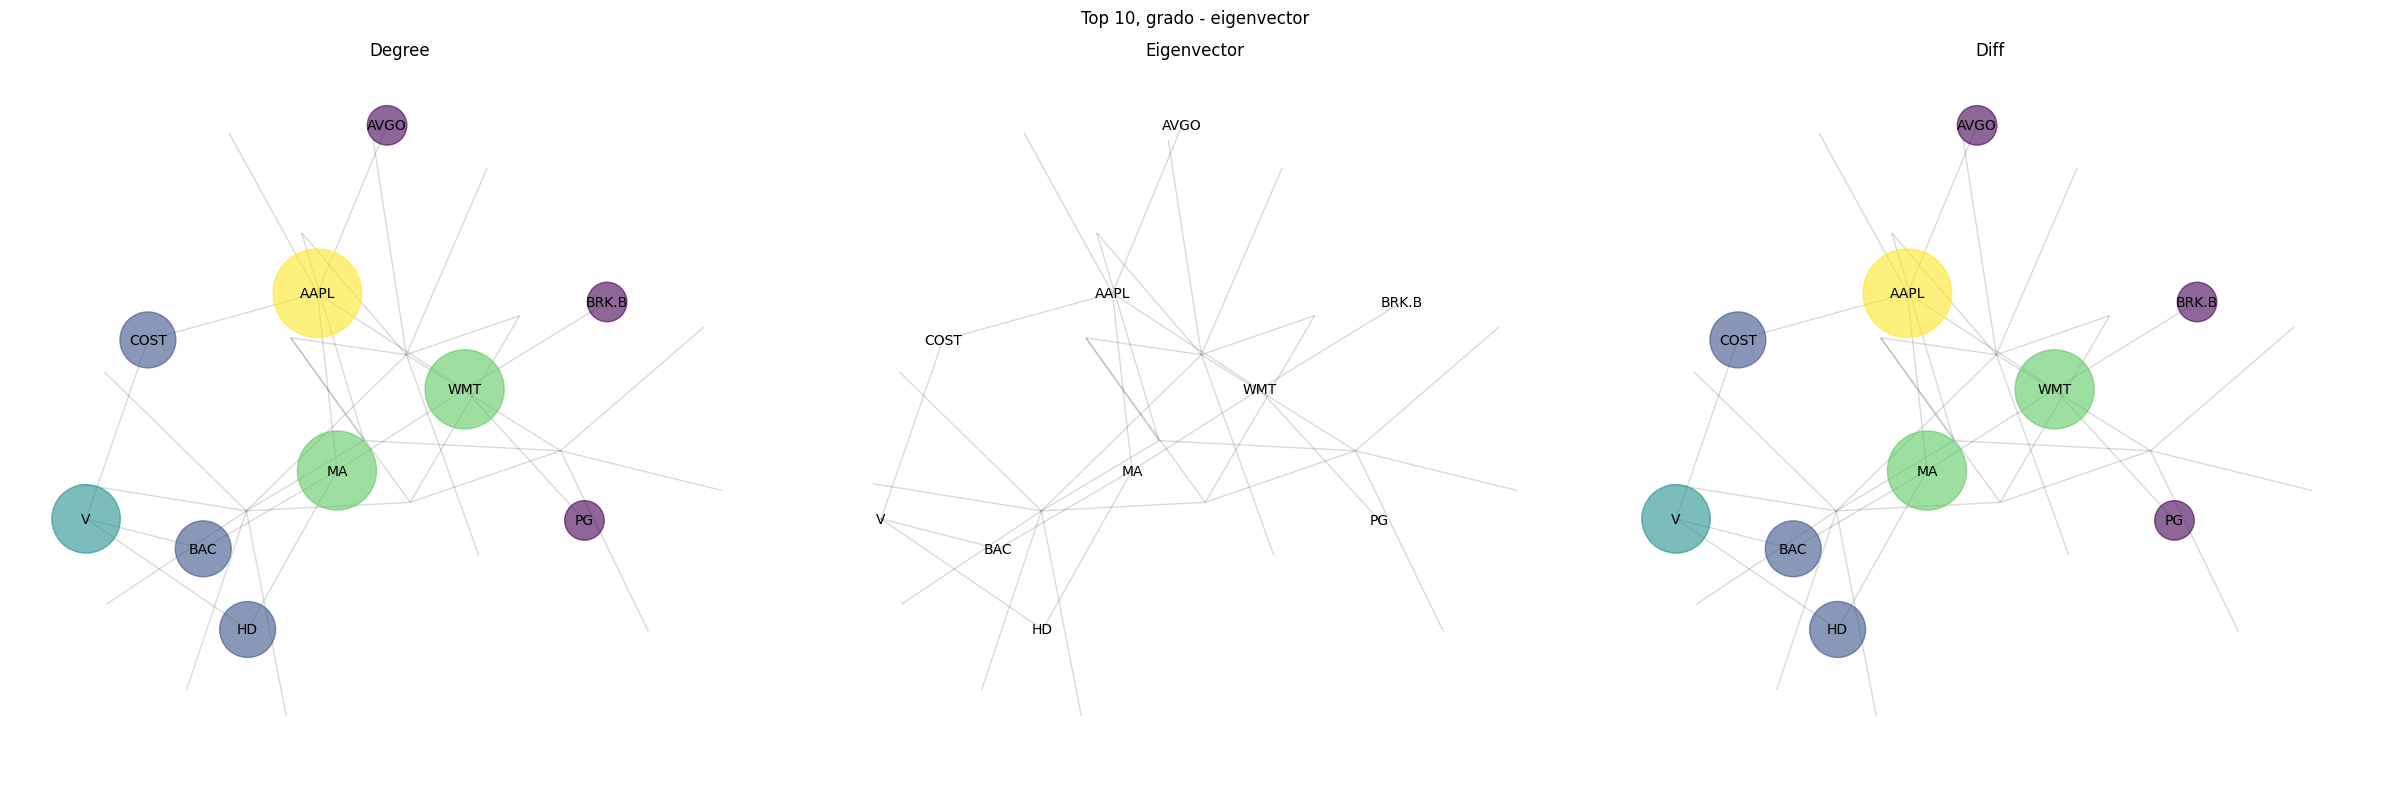

In [58]:
plot_centralidades(
    top_pos=top_pos, title='Top 10, grado - eigenvector', nodesize=60000)

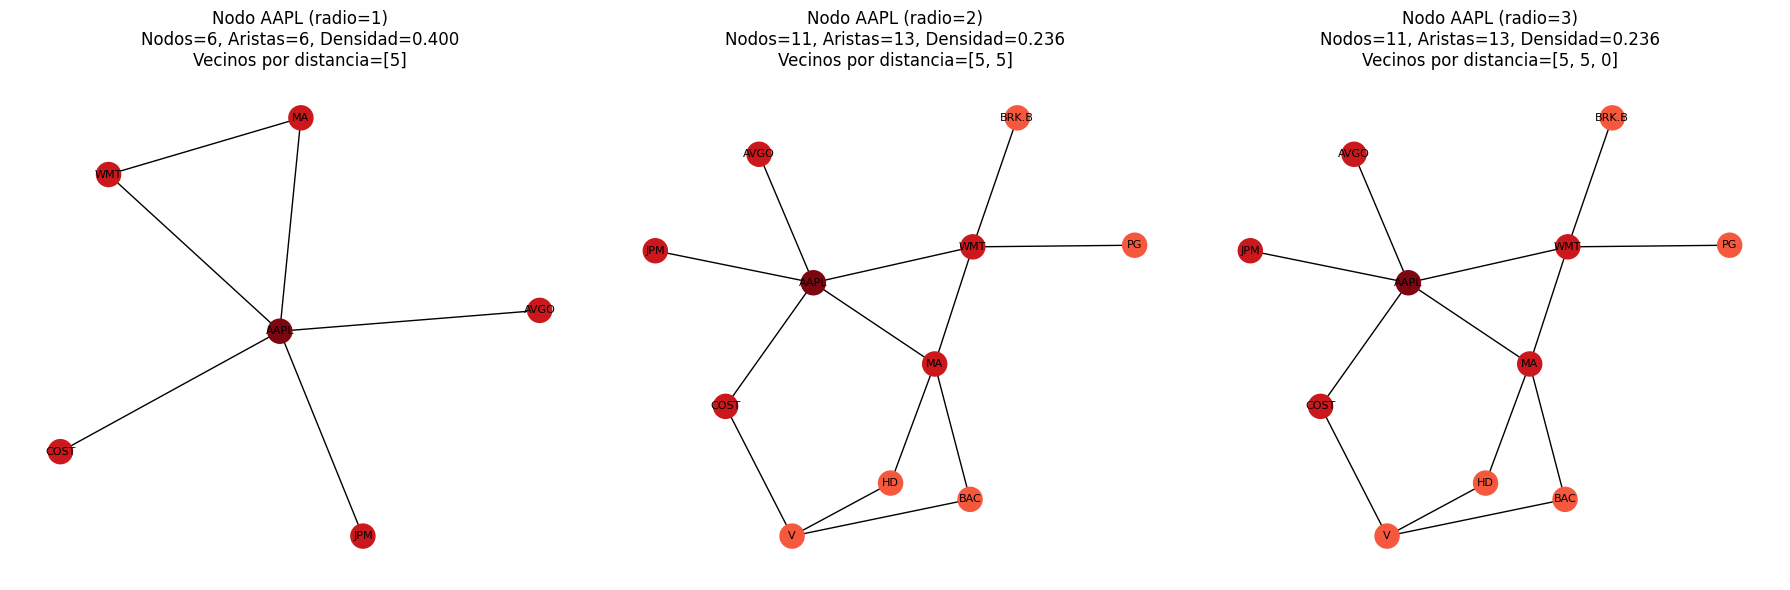

In [59]:
maxpos_node, maxpos_val = max(diff.items(), key=lambda kv: kv[1])
plot_ego_radii_3panel(G, maxpos_node, layout="kamada_kawai")

# Top Negativos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen vecinos muy importantes y tienen pocos vecinos, o estan muy bien posicionados, pero no por tener muchos vecinos, sino porque los vecinos de los vecinos estan muy bien posicionados

Contagian directamente a pocos, pero se propaga mucho


**ORCL solo se conecta con otras 3 empresas, pero por sus vecinos la componente mas grande de la red se completa en 3 pasos**

In [60]:
df_top_neg = tabla(top_pos=top_neg, digits=4)

,node,degree,eigenvector,diff
0,ORCL,0.0405,0.0759,-0.0354
1,PLTR,0.0541,0.0862,-0.0322
2,AMD,0.0541,0.0862,-0.0322
3,GOOGL,0.0270,0.0539,-0.0268
4,TSLA,0.0270,0.0539,-0.0268
5,GOOG,0.0135,0.0318,-0.0183
6,META,0.0135,0.0318,-0.0183
7,MU,0.0135,0.0318,-0.0183
8,NVDA,0.1081,0.1244,-0.0163
9,LLY,0.0135,0.0289,-0.0153


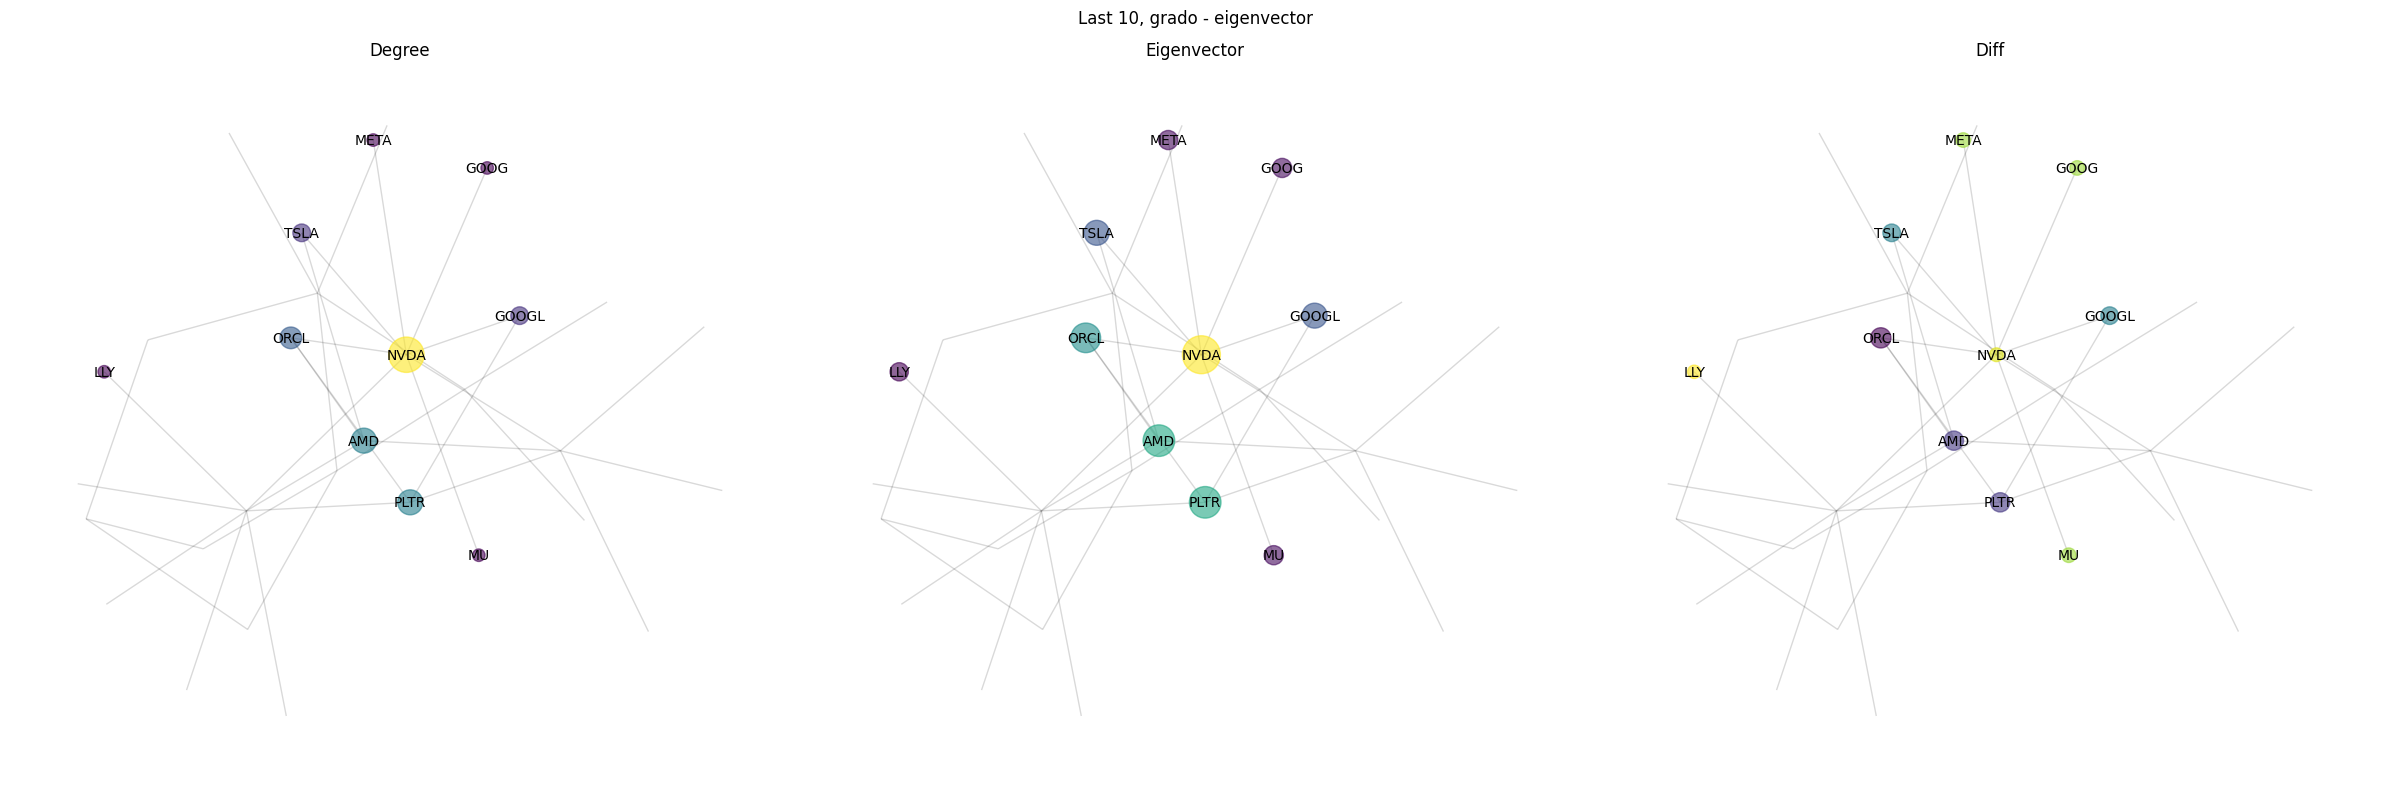

In [61]:
plot_centralidades(
    top_pos=top_neg, title='Last 10, grado - eigenvector', nodesize=6000)

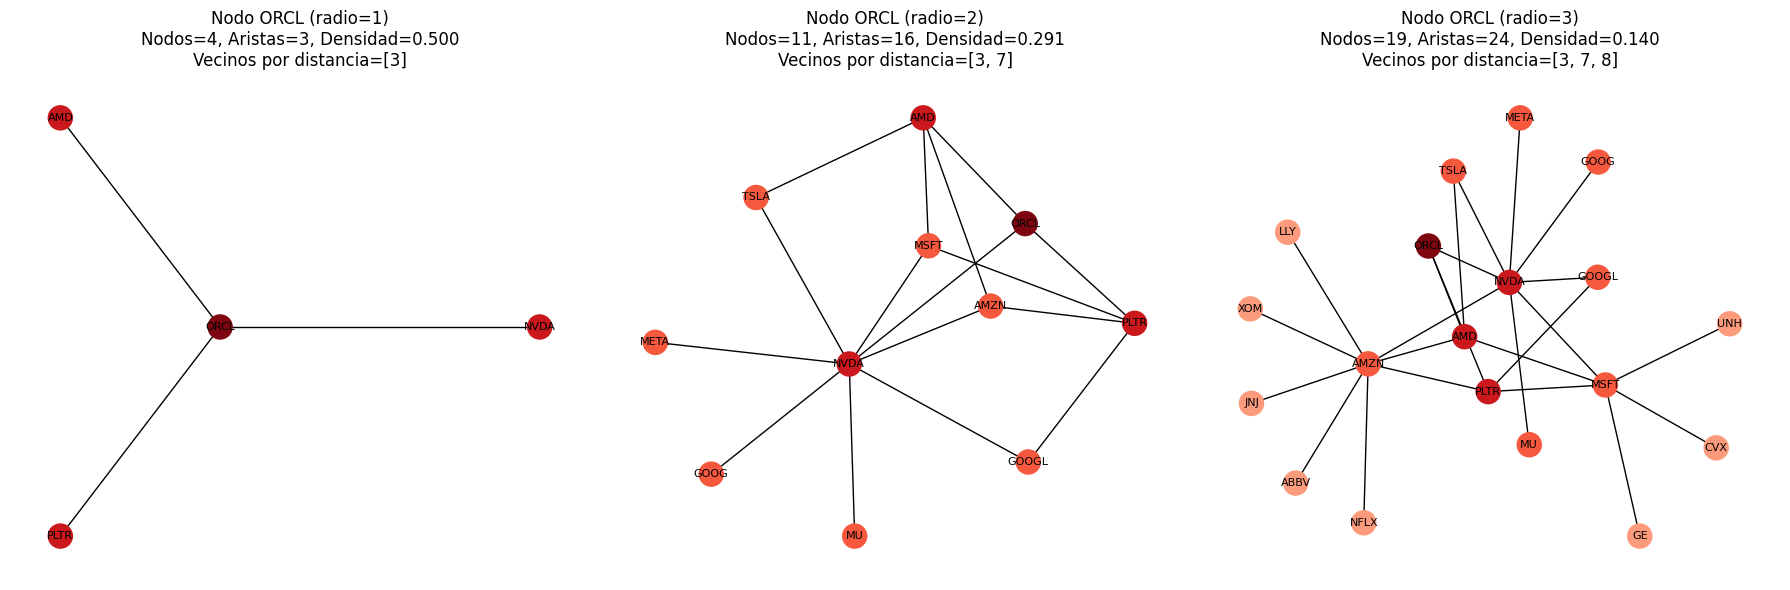

In [62]:
maxneg_node, maxneg_val = min(diff.items(), key=lambda kv: kv[1])
plot_ego_radii_3panel(G, maxneg_node, layout="kamada_kawai")

# Top cercanos a 0


Los nodos que tienen la menor diferencia es porque es parecido cuanto pesan sus conexiones a la calidad de los nodos a los que estan conectados. Son parecidos a una red conexa, en una red conexa la diferencia de las centralidades ponderadas es 0

Justo en sus vecinos a radio = 1, se forma un $K_3$; mientras mas avanza el radio mas se va perdiendo la red completamente conexa, pero esa es la idea. En la red que estamos usando, este es el cluster mas parecido a una red completamente conexa, como un grupo de amigos que son muy amigos entre ellos.

Su densidad deberia ser la mas alta.


**Aunque AAPL forme un grafo mas denso que AMD, AAPL esta en la segunda componente, entonces su diferencia es grande. El nodo que forma subredes mas densas de la componente mas grande es AMZN**

In [63]:
df_closest0 = tabla(top_pos=closest0, digits=4)

,node,degree,eigenvector,diff
0,AMZN,0.1081,0.1128,-0.0047
1,GE,0.0135,0.0242,-0.0106
2,CVX,0.0135,0.0242,-0.0106
3,UNH,0.0135,0.0242,-0.0106
4,MSFT,0.0811,0.0945,-0.0134
5,AVGO,0.0135,0.0000,0.0135
6,JPM,0.0135,0.0000,0.0135
7,BRK.B,0.0135,0.0000,0.0135
8,PG,0.0135,0.0000,0.0135
9,LLY,0.0135,0.0289,-0.0153


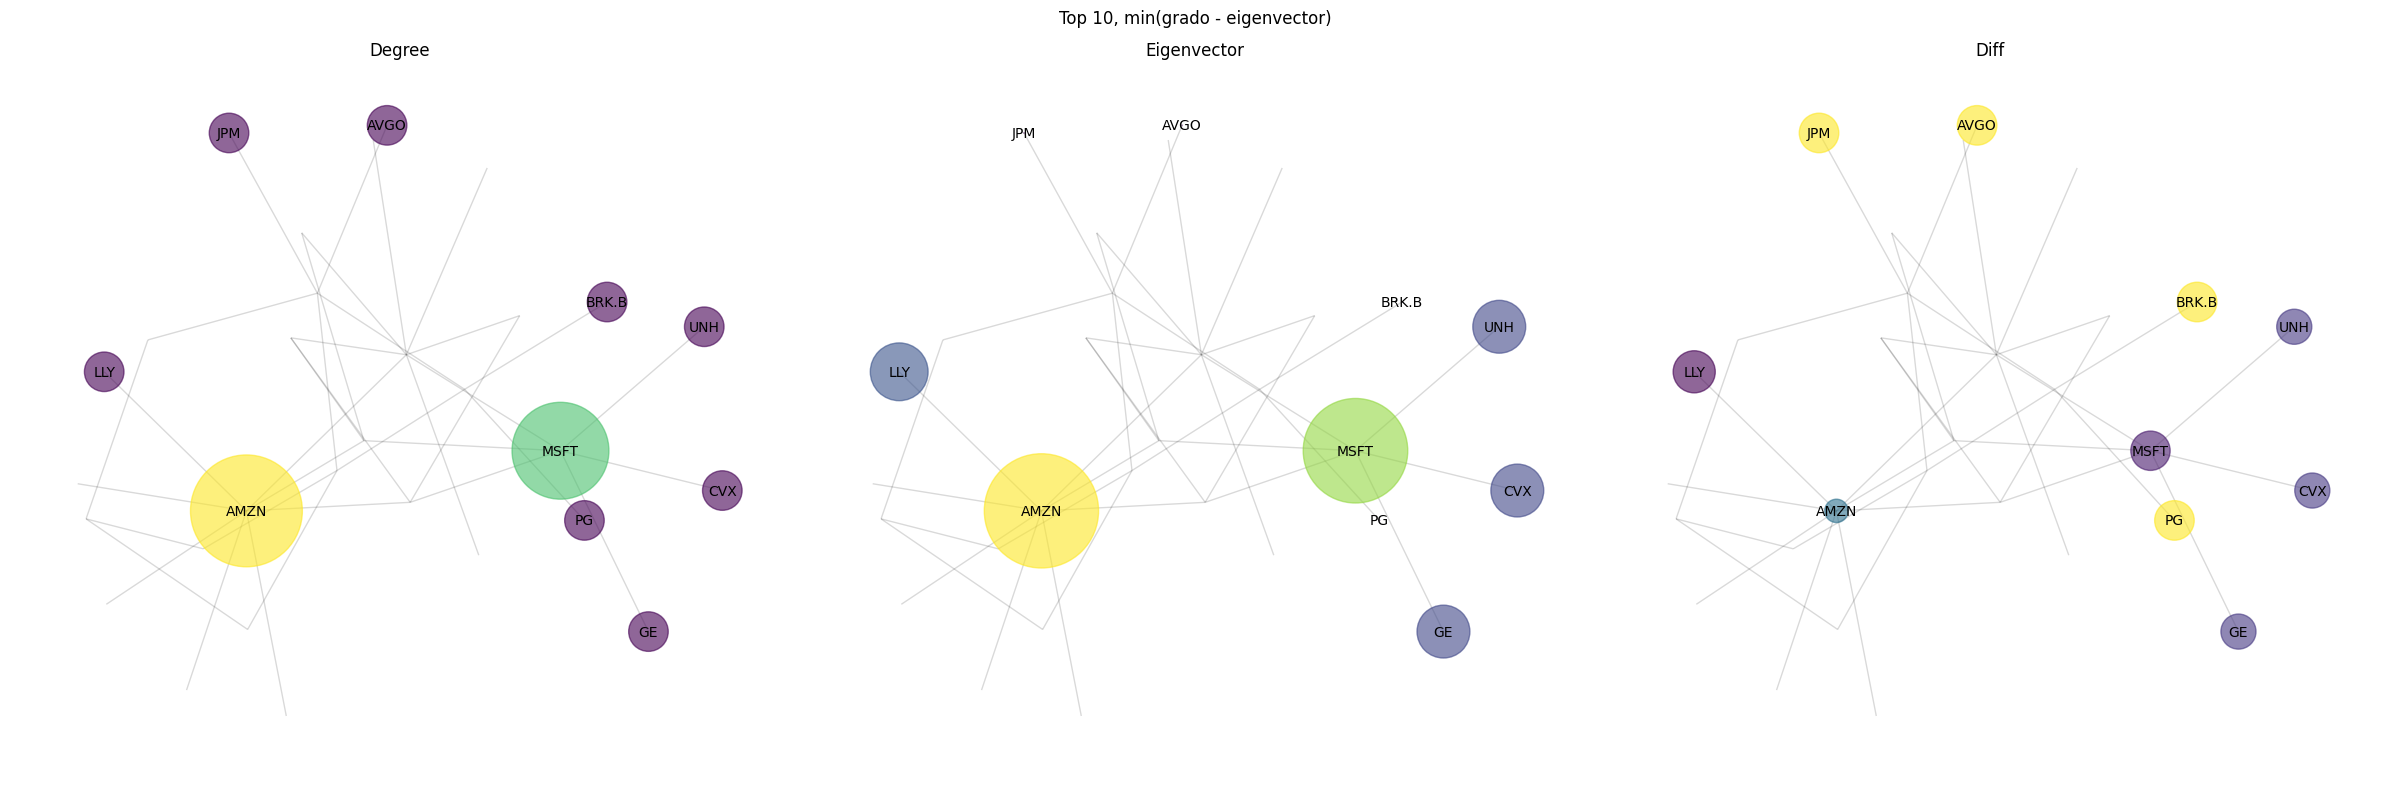

In [64]:
plot_centralidades(
    top_pos=closest0, title='Top 10, min(grado - eigenvector)', nodesize=60000)

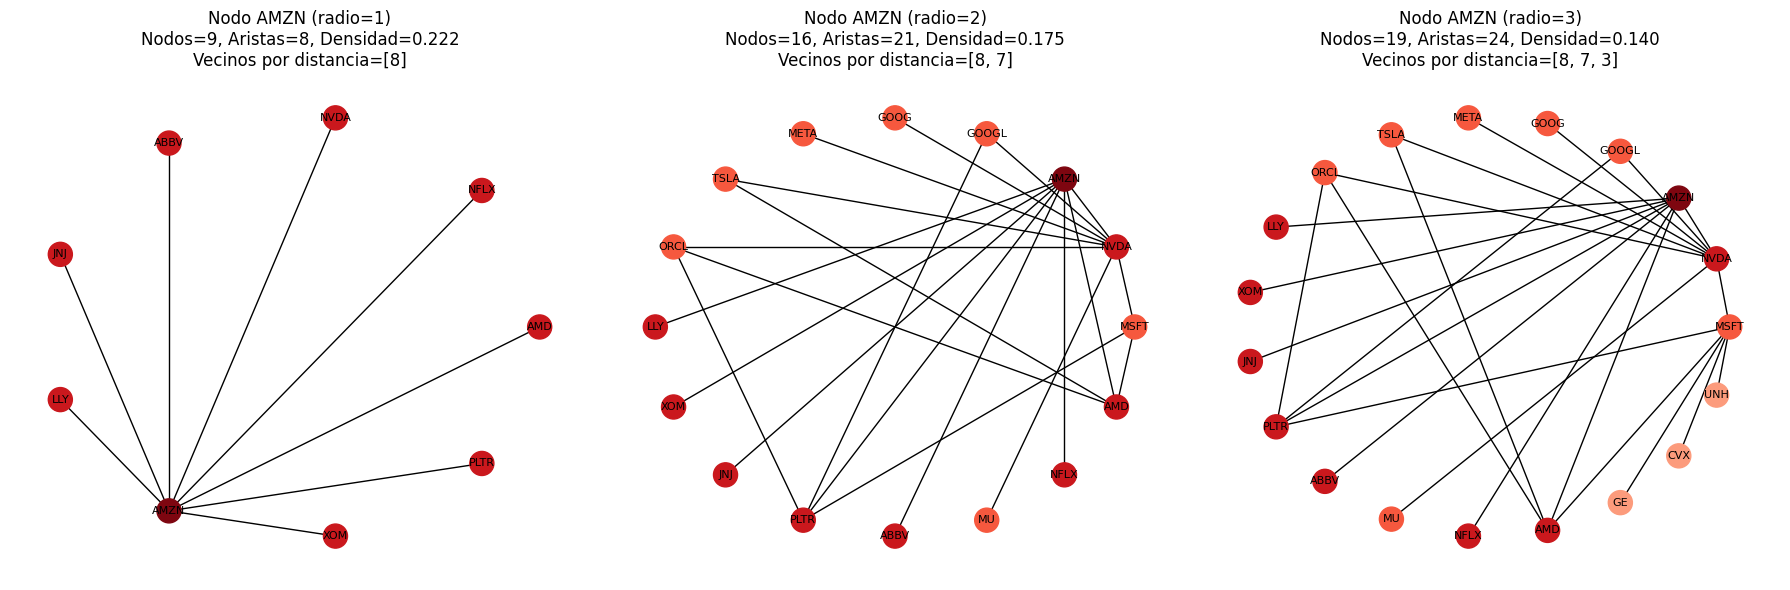

In [65]:
closest_node, closest_val = min(diff.items(), key=lambda kv: abs(kv[1]))
plot_ego_radii_3panel(G, closest_node, layout="circular")

# Top alejados


Los que tienen la diferencia mas grande, es porque estan conectados a otros de los nodos mas importantes de la red y tienen pocas conexiones, JAJA como Hugo, que es amigo de Steve Jobs, Elon Musk y Bill Gates o no me acuerdo quien era el ultimo (Steve Jobs ya no); o son los nodos que tienen muchisimas conexiones y sus vecinos no.


**El que tiene mas diferencia de sus las coapariciones en las que aparece es Obi-Wan, es el que, en comparacion, sus coapariciones son menos significativas en relacion al total de sus coapariciones, porque sus vecinos casi no salen con mas**


In [66]:
df_furthest = tabla(top_pos=furthest, digits=4)

,node,degree,eigenvector,diff
0,AAPL,0.0676,0.0000,0.0676
1,WMT,0.0541,0.0000,0.0540
2,MA,0.0541,0.0000,0.0540
3,V,0.0405,0.0000,0.0405
4,ORCL,0.0405,0.0759,-0.0354
5,PLTR,0.0541,0.0862,-0.0322
6,AMD,0.0541,0.0862,-0.0322
7,BAC,0.0270,0.0000,0.0270
8,HD,0.0270,0.0000,0.0270
9,COST,0.0270,0.0000,0.0270


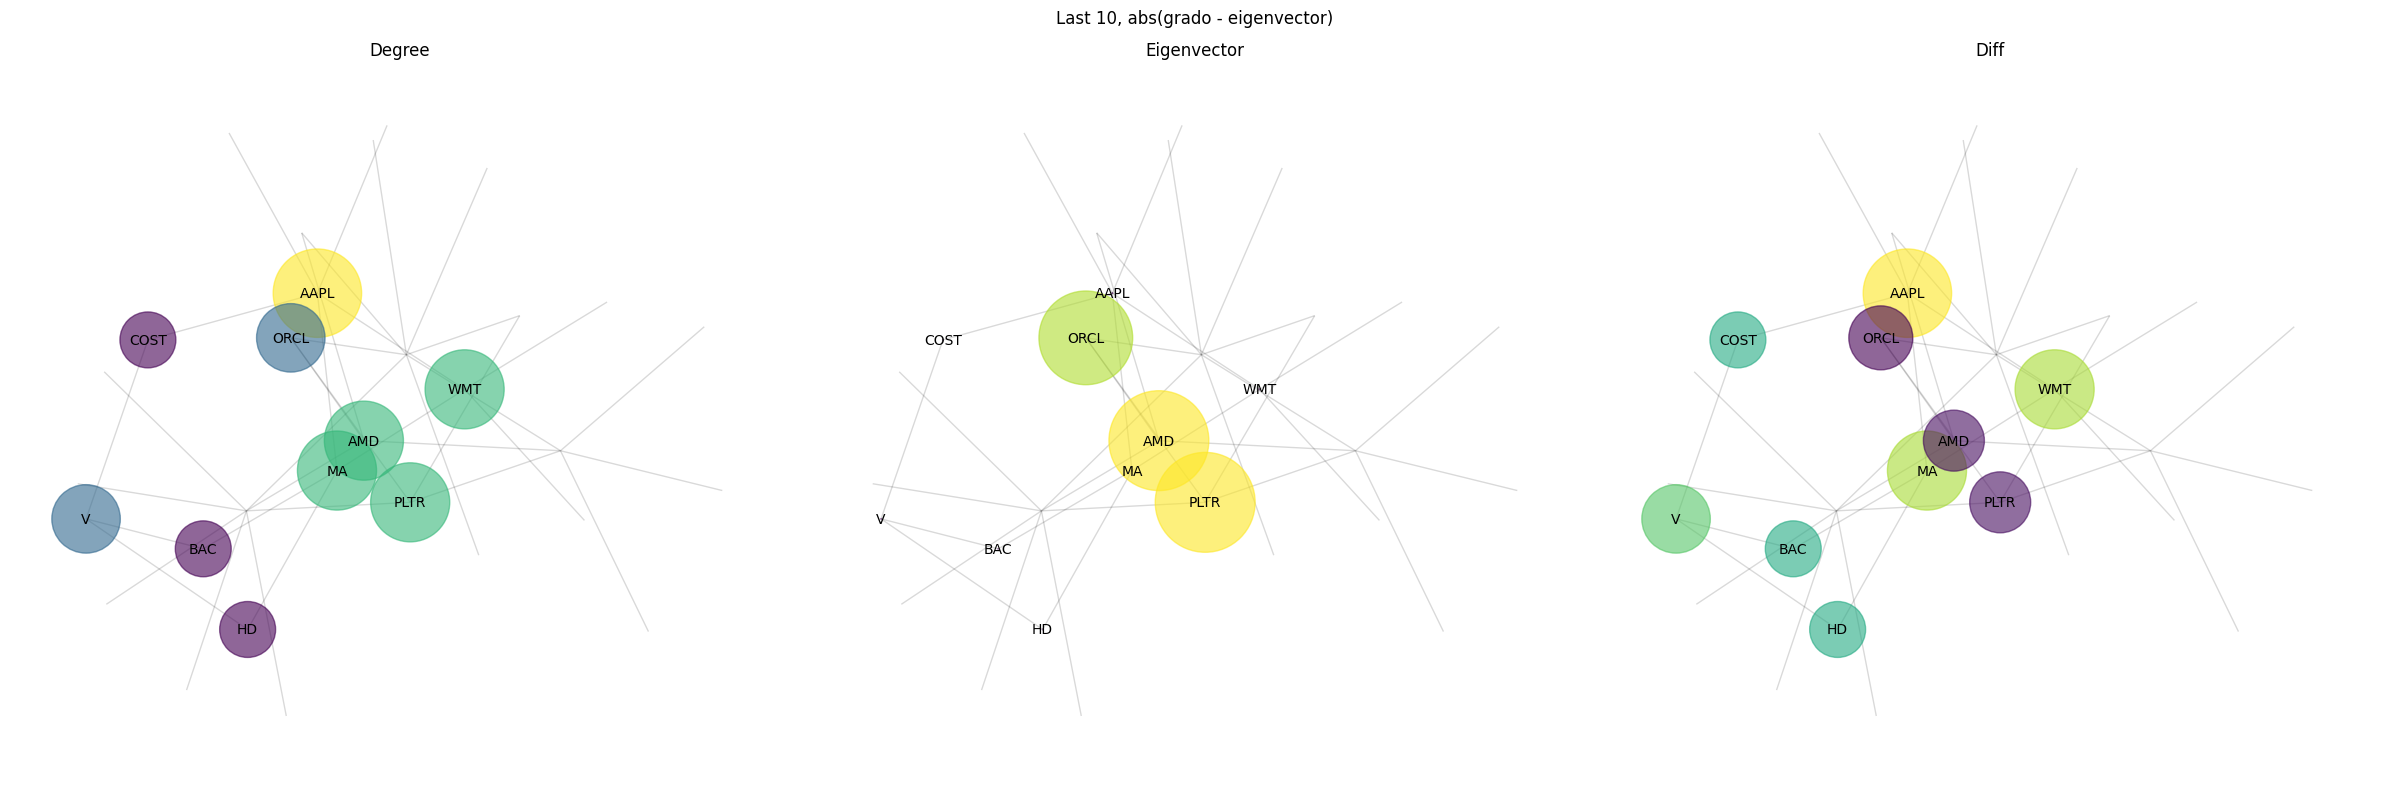

In [67]:
plot_centralidades(
    top_pos=furthest, title='Last 10, abs(grado - eigenvector)', nodesize=60000)

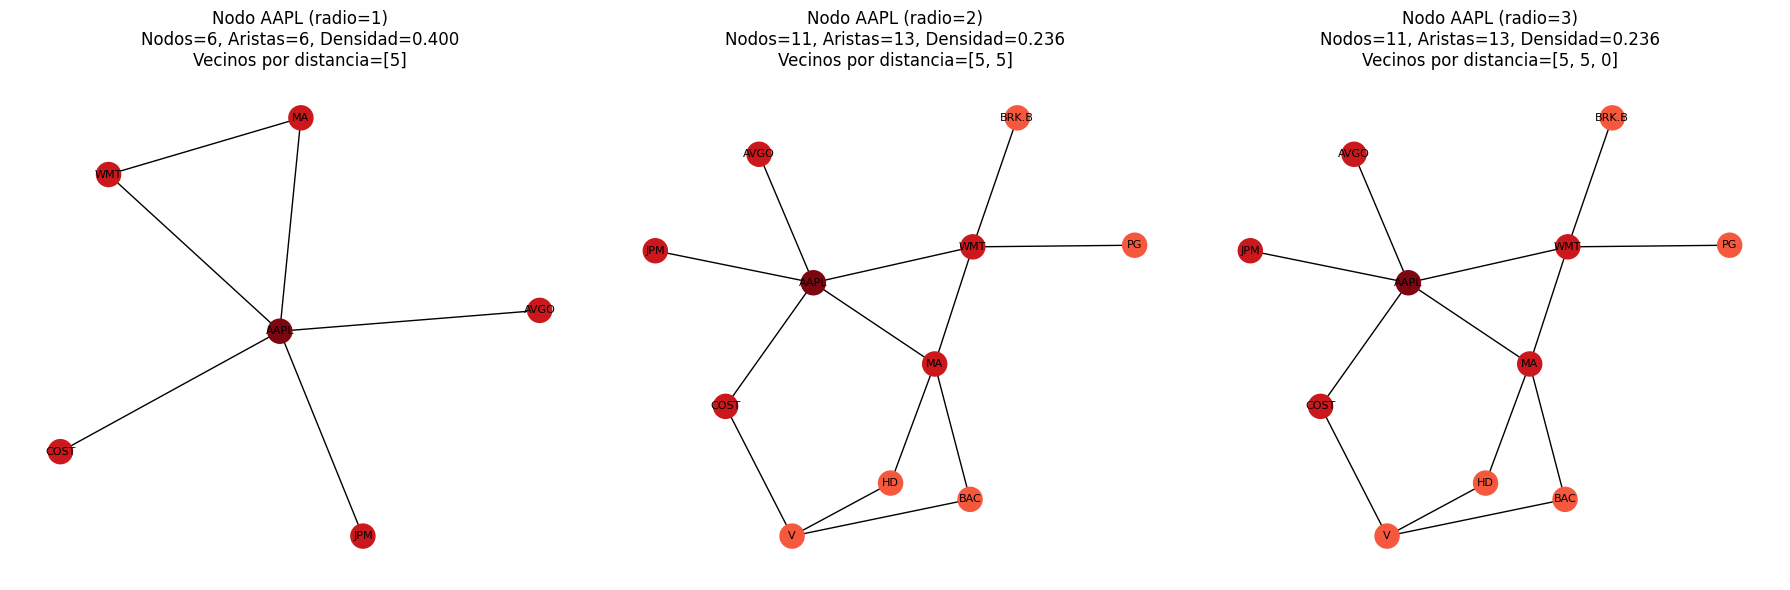

In [68]:
closest_node, closest_val = max(diff.items(), key=lambda kv: abs(kv[1]))
plot_ego_radii_3panel(G, closest_node)